In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# El nombre archivo
ruta_archivo = 'sensor_readings_24.data'

# Creamos los nombres de las columnas: 24 sensores + la acción final
columnas = [f'Sensor_{i}' for i in range(1, 25)] + ['Accion']

# Cargamos los datos indicando que no tiene fila de encabezado
df = pd.read_csv(ruta_archivo, header=None, names=columnas)

# Mostramos las primeras 5 filas para confirmar que cargó bien
print("Dimensión del dataset (Filas, Columnas):", df.shape)
display(df.head())

Dimensión del dataset (Filas, Columnas): (5456, 25)


,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Sensor_22,Sensor_23,Sensor_24,Accion
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


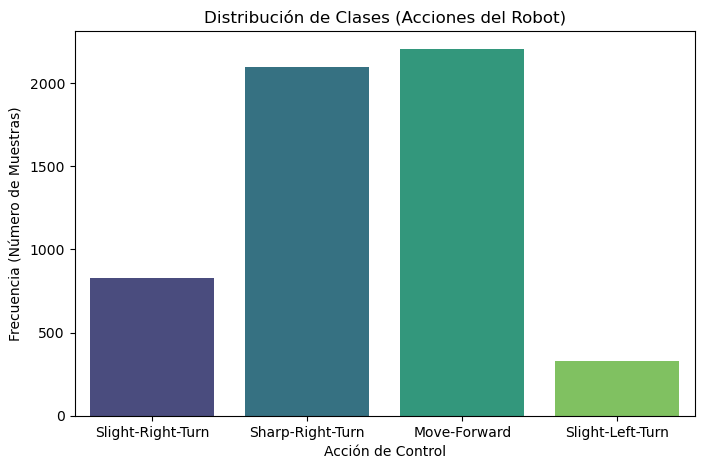

Porcentaje de muestras por acción:
Accion
Move-Forward         40.414223
Sharp-Right-Turn     38.434751
Slight-Right-Turn    15.139296
Slight-Left-Turn      6.011730
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Accion', hue='Accion', palette='viridis', legend=False)
plt.title('Distribución de Clases (Acciones del Robot)')
plt.xlabel('Acción de Control')
plt.ylabel('Frecuencia (Número de Muestras)')
plt.show()

# Imprimir porcentajes exactos para análisis
print("Porcentaje de muestras por acción:")
print(df['Accion'].value_counts(normalize=True) * 100)

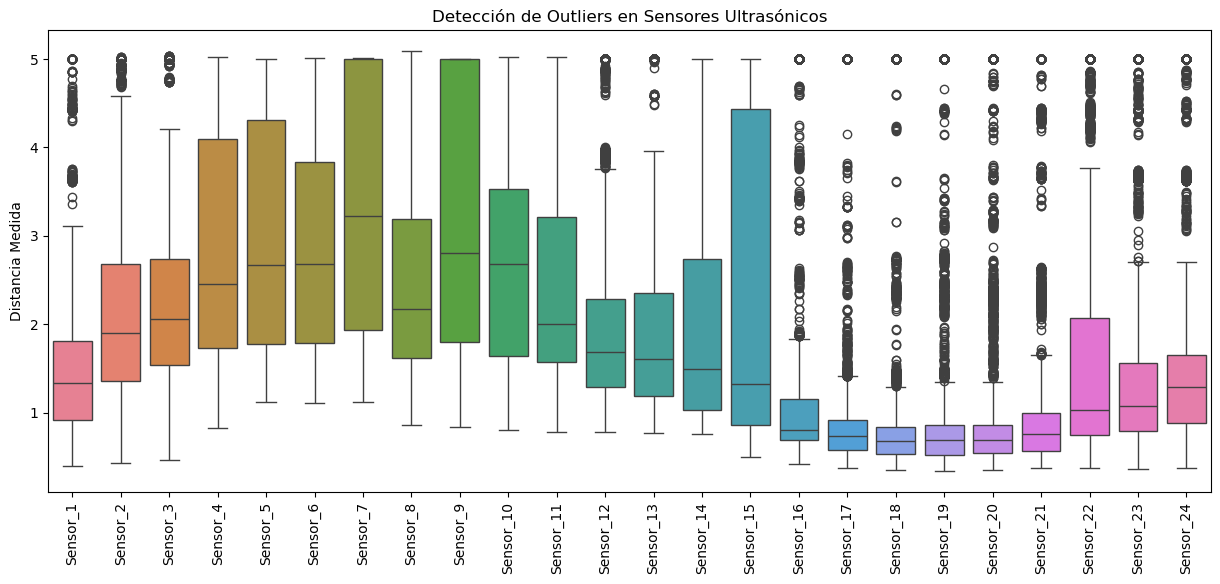

In [3]:
plt.figure(figsize=(15, 6))
# Graficamos solo las columnas de los sensores (sin la variable objetivo)
sns.boxplot(data=df.drop('Accion', axis=1), orient='v')
plt.title('Detección de Outliers en Sensores Ultrasónicos')
plt.ylabel('Distancia Medida')
plt.xticks(rotation=90)
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Separar características (X) y variable objetivo (y)
X = df.drop('Accion', axis=1)
y = df['Accion']

# Inicializar y aplicar el Z-score scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir de nuevo a DataFrame para visualizar
# Usamos X.columns para obtener los nombres directamente
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Media de las características escaladas")
print(X_scaled_df.mean().round(2).head()) # Mostramos solo los primeros 5 sensores

Media de las características escaladas
Sensor_1    0.0
Sensor_2   -0.0
Sensor_3   -0.0
Sensor_4    0.0
Sensor_5    0.0
dtype: float64


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- 1. Codificar las etiquetas de texto a números ---
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df['Accion'])

# --- 2. Partición Rigurosa ---
# Primero separamos el 70% para entrenamiento y el 30% restante
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# Luego dividimos ese 30% restante en dos mitades iguales (15% Valid, 15% Test)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- 3. Conversión a Tensores de PyTorch ---
# Las redes neuronales en PyTorch requieren que los datos estén en formato 'Tensor'
X_train = torch.tensor(X_train_raw, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.long)

X_val = torch.tensor(X_val_raw, dtype=torch.float32)
y_val = torch.tensor(y_val_raw, dtype=torch.long)

X_test = torch.tensor(X_test_raw, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.long)

print(f"Tamaño de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de Validación: {X_val.shape[0]} muestras")
print(f"Tamaño de Prueba: {X_test.shape[0]} muestras")

Tamaño de Entrenamiento: 3819 muestras
Tamaño de Validación: 818 muestras
Tamaño de Prueba: 819 muestras


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class ControladorRobotMLP(nn.Module):
    def __init__(self, input_size=24, num_classes=4):
        super(ControladorRobotMLP, self).__init__()
        
        # Capa de entrada: 24 sensores -> 64 neuronas ocultas
        self.fc1 = nn.Linear(input_size, 64)
        
        # Capa oculta: 64 neuronas -> 32 neuronas
        self.fc2 = nn.Linear(64, 32)
        
        # Capa de salida: 32 neuronas -> 4 acciones (clases)
        self.out = nn.Linear(32, num_classes)
        
    def forward(self, x):
        # Aplicamos la función de activación ReLU en las capas ocultas
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # La salida no lleva activación aquí porque usaremos CrossEntropyLoss, 
        # que ya incluye Softmax internamente.
        x = self.out(x)
        return x

# Instanciamos el modelo para verificarlo
modelo = ControladorRobotMLP()
print(modelo)

ControladorRobotMLP(
  (fc1): Linear(in_features=24, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=4, bias=True)
)


In [7]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- Hiperparámetros ---
batch_size = 64
learning_rate = 0.001
num_epochs = 150

# Empaquetar los tensores en Datasets de PyTorch
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Crear los DataLoaders (para iterar en lotes)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

# Instanciar el modelo, la función de pérdida y el optimizador
modelo = ControladorRobotMLP()
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=learning_rate)

print("DataLoaders e hiperparámetros configurados correctamente.")

DataLoaders e hiperparámetros configurados correctamente.


In [8]:
# Listas para guardar el historial y poder graficar después
historial_loss_train, historial_acc_train = [], []
historial_loss_val, historial_acc_val = [], []

print("Iniciando entrenamiento...")

for epoch in range(num_epochs):
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()
    loss_train_acumulada = 0.0
    correctos_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        optimizador.zero_grad() # Limpiar gradientes
        
        outputs = modelo(inputs) # Forward pass
        loss = criterio(outputs, labels) # Calcular error
        loss.backward() # Backward pass (calcular gradientes)
        optimizador.step() # Actualizar pesos
        
        loss_train_acumulada += loss.item() * inputs.size(0)
        _, predicciones = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correctos_train += (predicciones == labels).sum().item()
        
    acc_train = correctos_train / total_train
    loss_train = loss_train_acumulada / total_train
    historial_loss_train.append(loss_train)
    historial_acc_train.append(acc_train)
    
    # --- FASE DE VALIDACIÓN ---
    modelo.eval() # Modo evaluación (apaga Dropout/BatchNorm si los hubiera)
    loss_val_acumulada = 0.0
    correctos_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calcular gradientes para ahorrar memoria y tiempo
        for inputs, labels in val_loader:
            outputs = modelo(inputs)
            loss = criterio(outputs, labels)
            
            loss_val_acumulada += loss.item() * inputs.size(0)
            _, predicciones = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correctos_val += (predicciones == labels).sum().item()
            
    acc_val = correctos_val / total_val
    loss_val = loss_val_acumulada / total_val
    historial_loss_val.append(loss_val)
    historial_acc_val.append(acc_val)
    
    # Imprimir progreso cada 25 épocas
    if (epoch+1) % 25 == 0:
        print(f'Época [{epoch+1}/{num_epochs}] | Train Loss: {loss_train:.4f}, Train Acc: {acc_train:.4f} | Val Loss: {loss_val:.4f}, Val Acc: {acc_val:.4f}')

print("¡Entrenamiento finalizado!")

Iniciando entrenamiento...
Época [25/150] | Train Loss: 0.1944, Train Acc: 0.9335 | Val Loss: 0.2568, Val Acc: 0.9034
Época [50/150] | Train Loss: 0.1010, Train Acc: 0.9699 | Val Loss: 0.2242, Val Acc: 0.9193
Época [75/150] | Train Loss: 0.0686, Train Acc: 0.9804 | Val Loss: 0.2464, Val Acc: 0.9193
Época [100/150] | Train Loss: 0.0510, Train Acc: 0.9811 | Val Loss: 0.2775, Val Acc: 0.9169
Época [125/150] | Train Loss: 0.0448, Train Acc: 0.9840 | Val Loss: 0.2935, Val Acc: 0.9242
Época [150/150] | Train Loss: 0.0364, Train Acc: 0.9861 | Val Loss: 0.3430, Val Acc: 0.9144
¡Entrenamiento finalizado!


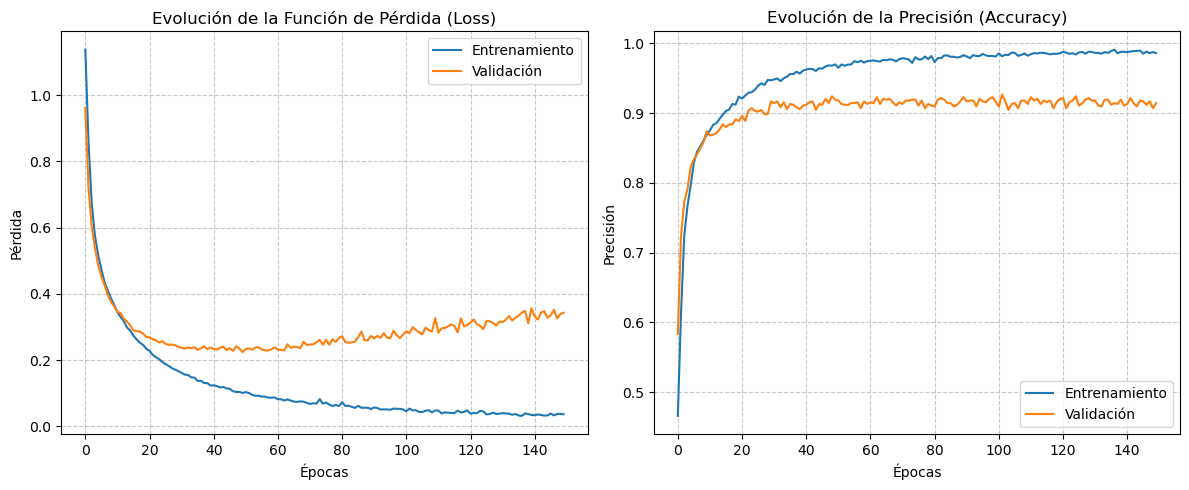

In [9]:
plt.figure(figsize=(12, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(historial_loss_train, label='Entrenamiento')
plt.plot(historial_loss_val, label='Validación')
plt.title('Evolución de la Función de Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(historial_acc_train, label='Entrenamiento')
plt.plot(historial_acc_val, label='Validación')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

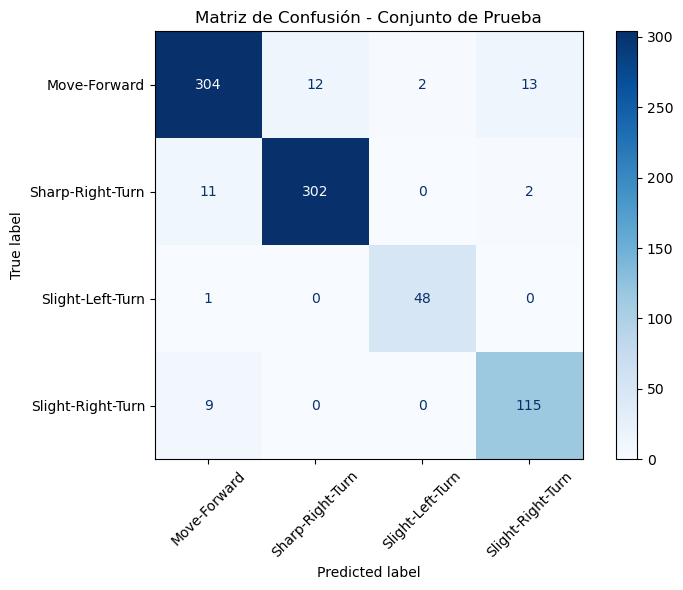


--- Análisis para Despliegue en Edge AI ---
Número total de parámetros entrenables: 3812


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Generar la Matriz de Confusión sobre el Test Set ---
modelo.eval() # Modo evaluación
with torch.no_grad():
    outputs_test = modelo(X_test)
    _, predicciones_test = torch.max(outputs_test.data, 1)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, predicciones_test)
nombres_clases = encoder.classes_ # Recuperamos los nombres originales: Move-Forward, etc.

# Graficar
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2. Calcular la Carga Computacional ---
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"\n--- Análisis para Despliegue en Edge AI ---")
print(f"Número total de parámetros entrenables: {total_params}")